# Evaluation Pipeline 4.28

End-to-end comparison of **two synthetic groups** against **real** data on the same numeric feature space.

**Flow:** Config → load/align → **A** summary stats + MAD → **B** marginal distances (bootstrap) → **C** geometry (UMAP + structure bootstrap) → **D** correlation heatmaps + scalar bootstrap.

**Branch:** `USE_SHARED_REAL_FOR_ALL_GENERATORS` controls whether both groups share one real file (combined figures) or use separate reals (one figure per group where noted).

**Bootstrap:** `N_BOOTSTRAP` and `BOOTSTRAP_RANDOM_SEED` are set once in Chunk 2 and reused in B, C.2, and D.2.

In [9]:
# Chunk 1 — Setup. Imports and display defaults.
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

In [10]:
# Chunk 2 — Config. Paths, shared vs separate real, and global bootstrap (B / C.2 / D.2).

BASE_DIR = Path(r"D:\CYX\study\research\li-xuan qin\SyNG-BTS\syng_bts_test\python - 4.28")

# -----------------------------------------------------------------
# Branch switch:
# True  -> both generated groups use the SAME real dataset
# False -> each generated group uses its own real dataset
# -----------------------------------------------------------------
USE_SHARED_REAL_FOR_ALL_GENERATORS = True

# Shared real file (used only when switch=True)
SHARED_REAL_FILE = "processed_train_136_full_model_data_yj_transformed_zscaled.csv"

# Group 1 generated file
GEN_1_FILE = "processed_train_136_full_model_data_yj_transformed_zscaled_epochES_batch01_maf_generated.csv"

# Group 2 generated file
GEN_2_FILE = "processed_train_136_full_model_data_yj_transformed_zscaled_epochES_batch01_CVAE1-1_generated.csv"

# Separate real files (used only when switch=False)
REAL_1_FILE = "processed_train_136_full_model_data_yj_transformed_zscaled.csv"
REAL_2_FILE = "processed_train_136_full_model_data_yj_transformed_zscaled.csv"

N_BOOTSTRAP = 300
BOOTSTRAP_RANDOM_SEED = 42

if USE_SHARED_REAL_FOR_ALL_GENERATORS:
    generation_groups = {
        "gen_group_1": {
            "real_path": BASE_DIR / SHARED_REAL_FILE,
            "gen_path": BASE_DIR / GEN_1_FILE,
        },
        "gen_group_2": {
            "real_path": BASE_DIR / SHARED_REAL_FILE,
            "gen_path": BASE_DIR / GEN_2_FILE,
        },
    }
else:
    generation_groups = {
        "gen_group_1": {
            "real_path": BASE_DIR / REAL_1_FILE,
            "gen_path": BASE_DIR / GEN_1_FILE,
        },
        "gen_group_2": {
            "real_path": BASE_DIR / REAL_2_FILE,
            "gen_path": BASE_DIR / GEN_2_FILE,
        },
    }

print("Configured mode:", "SHARED real" if USE_SHARED_REAL_FOR_ALL_GENERATORS else "SEPARATE reals")
print(f"Bootstrap: N_BOOTSTRAP={N_BOOTSTRAP}, BOOTSTRAP_RANDOM_SEED={BOOTSTRAP_RANDOM_SEED}")
print("Configured paths:")
for name, cfg in generation_groups.items():
    print(f"\n[{name}]")
    print(" real:", cfg["real_path"])
    print(" gen :", cfg["gen_path"])
    if not cfg["real_path"].exists():
        print("  -> WARNING: real file not found")
    if not cfg["gen_path"].exists():
        print("  -> WARNING: generated file not found")

Configured mode: SHARED real
Bootstrap: N_BOOTSTRAP=300, BOOTSTRAP_RANDOM_SEED=42
Configured paths:

[gen_group_1]
 real: D:\CYX\study\research\li-xuan qin\SyNG-BTS\syng_bts_test\python - 4.28\processed_train_136_full_model_data_yj_transformed_zscaled.csv
 gen : D:\CYX\study\research\li-xuan qin\SyNG-BTS\syng_bts_test\python - 4.28\processed_train_136_full_model_data_yj_transformed_zscaled_epochES_batch01_maf_generated.csv

[gen_group_2]
 real: D:\CYX\study\research\li-xuan qin\SyNG-BTS\syng_bts_test\python - 4.28\processed_train_136_full_model_data_yj_transformed_zscaled.csv
 gen : D:\CYX\study\research\li-xuan qin\SyNG-BTS\syng_bts_test\python - 4.28\processed_train_136_full_model_data_yj_transformed_zscaled_epochES_batch01_CVAE1-1_generated.csv


In [11]:
# Chunk 3 — Data. Load CSVs, align numeric columns, median-impute → dict `prepared`.

LABEL_CANDIDATES = ["groups", "groups2"]

def load_real_df(path: Path) -> pd.DataFrame:
    return pd.read_csv(path)

def load_gen_df(path: Path, real_columns: list[str]) -> pd.DataFrame:
    # Generated files are typically saved without headers.
    gen_raw = pd.read_csv(path, header=None)
    if gen_raw.shape[1] != len(real_columns):
        raise ValueError(
            f"Generated column mismatch: gen has {gen_raw.shape[1]} cols, real has {len(real_columns)} cols."
        )
    gen_raw.columns = real_columns
    return gen_raw

def extract_numeric_features(df: pd.DataFrame) -> pd.DataFrame:
    to_drop = [c for c in LABEL_CANDIDATES if c in df.columns]
    out = df.drop(columns=to_drop, errors="ignore")
    out = out.select_dtypes(include=[np.number]).copy()
    out = out.replace([np.inf, -np.inf], np.nan)
    return out

def align_feature_space(real_x: pd.DataFrame, gen_x: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    common_cols = [c for c in real_x.columns if c in gen_x.columns]
    if len(common_cols) == 0:
        raise ValueError("No common numeric features between real and generated data.")
    real_aligned = real_x[common_cols].copy()
    gen_aligned = gen_x[common_cols].copy()
    return real_aligned, gen_aligned

prepared = {}
for group_name, cfg in generation_groups.items():
    real_df = load_real_df(cfg["real_path"])
    gen_df = load_gen_df(cfg["gen_path"], real_df.columns.tolist())

    real_x = extract_numeric_features(real_df)
    gen_x = extract_numeric_features(gen_df)

    real_x, gen_x = align_feature_space(real_x, gen_x)

    # Fill NaN with column medians to keep statistic functions stable.
    real_x = real_x.apply(lambda s: s.fillna(s.median()), axis=0)
    gen_x = gen_x.apply(lambda s: s.fillna(s.median()), axis=0)

    prepared[group_name] = {
        "real": real_x,
        "gen": gen_x,
    }

    print(f"[{group_name}] real shape={real_x.shape}, gen shape={gen_x.shape}")

[gen_group_1] real shape=(604, 144), gen shape=(1000, 144)
[gen_group_2] real shape=(604, 144), gen shape=(1000, 144)


In [12]:
# Chunk 4 — A.1 Summary stats. Long table: per feature × statistic, real vs gen and |Δ|.

SUMMARY_STATS = {
    "mean": lambda s: float(s.mean()),
    "sd": lambda s: float(s.std(ddof=1)),
    "median": lambda s: float(s.median()),
    "iqr": lambda s: float(s.quantile(0.75) - s.quantile(0.25)),
    "skewness": lambda s: float(s.skew()),
    "kurtosis": lambda s: float(s.kurt()),
}

def build_feature_stat_table(real_x: pd.DataFrame, gen_x: pd.DataFrame, group_name: str) -> pd.DataFrame:
    rows = []
    for feat in real_x.columns:
        sr = real_x[feat]
        sg = gen_x[feat]
        for stat_name, fn in SUMMARY_STATS.items():
            rv = fn(sr)
            gv = fn(sg)
            rows.append({
                "group": group_name,
                "feature": feat,
                "statistic": stat_name,
                "real_value": rv,
                "gen_value": gv,
                "abs_diff": abs(rv - gv),
            })
    return pd.DataFrame(rows)

feature_stat_tables = []
for group_name, data_obj in prepared.items():
    tbl = build_feature_stat_table(data_obj["real"], data_obj["gen"], group_name)
    feature_stat_tables.append(tbl)

summary_feature_table = pd.concat(feature_stat_tables, ignore_index=True)
#print("Feature-level summary table shape:", summary_feature_table.shape)
#display(summary_feature_table.head(20))


4 datasets x 6 statistics (median across features):


,mean,sd,median,iqr,skewness,kurtosis
dataset,,,,,,
gen_group_1_real,0.000000,1.000829,0.000000,1.386522,0.000000,-0.180980
gen_group_1_generated,-0.020655,0.931332,-0.032528,1.259613,0.034973,-0.011797
gen_group_2_real,0.000000,1.000829,0.000000,1.386522,0.000000,-0.180980
gen_group_2_generated,0.007437,0.920853,0.002319,1.246735,0.032818,-0.033944


Absolute MAD (aggregated) table:


statistic,mean,sd,median,iqr,skewness,kurtosis
group,,,,,,
gen_group_1,0.021393,0.025765,0.04109,0.060859,0.095645,0.208157
gen_group_2,0.012606,0.024336,0.02226,0.059434,0.046538,0.112278


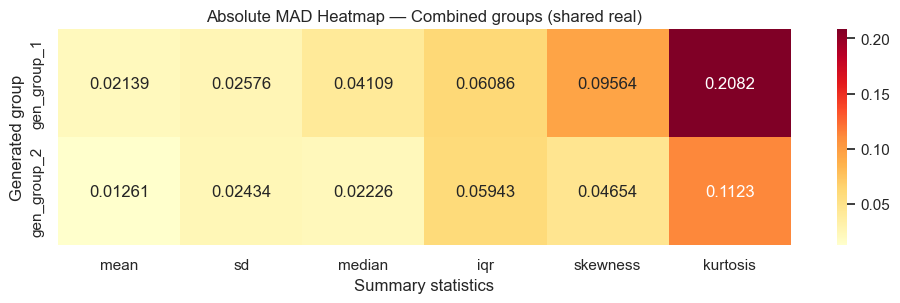

In [13]:
# Chunk 5 — A.2 Aggregate. Four-dataset median stats, absolute-MAD table, MAD heatmaps (branching).

def mad_1d(values: np.ndarray) -> float:
    v = np.asarray(values, dtype=float)
    med = np.median(v)
    return float(np.median(np.abs(v - med)))

def build_absolute_mad_series(feature_table: pd.DataFrame) -> pd.Series:
    # feature_table columns: group, feature, statistic, real_value, gen_value, abs_diff
    out = (
        feature_table.groupby("statistic")["abs_diff"]
        .apply(lambda x: mad_1d(x.to_numpy()))
        .reindex(list(SUMMARY_STATS.keys()))
    )
    return out

def build_dataset_stat_row(df_x: pd.DataFrame, dataset_name: str) -> dict:
    # Aggregate each statistic across features by median(feature-level statistic).
    row = {"dataset": dataset_name}
    for stat_name, fn in SUMMARY_STATS.items():
        feat_stats = df_x.apply(fn, axis=0).to_numpy(dtype=float)
        row[stat_name] = float(np.median(feat_stats))
    return row

# 4 rows (real/gen × groups) × 6 summary statistics (median across features)
dataset_rows = []
for group_name, data_obj in prepared.items():
    dataset_rows.append(build_dataset_stat_row(data_obj["real"], f"{group_name}_real"))
    dataset_rows.append(build_dataset_stat_row(data_obj["gen"], f"{group_name}_generated"))

dataset_stat_table = pd.DataFrame(dataset_rows).set_index("dataset")
print("4 datasets x 6 statistics (median across features):")
display(dataset_stat_table)

# Absolute MAD of |Δ| across features, per group
mad_by_group = {}
for group_name in prepared.keys():
    tbl_group = summary_feature_table[summary_feature_table["group"] == group_name].copy()
    mad_by_group[group_name] = build_absolute_mad_series(tbl_group)

mad_table = pd.DataFrame(mad_by_group).T
mad_table.index.name = "group"
print("Absolute MAD (aggregated) table:")
display(mad_table)

# MAD heatmaps: combined when shared real; one per group when separate reals
if USE_SHARED_REAL_FOR_ALL_GENERATORS:
    plt.figure(figsize=(10, 3.2))
    sns.heatmap(mad_table, annot=True, fmt=".4g", cmap="YlOrRd", cbar=True)
    plt.title("Absolute MAD Heatmap — Combined groups (shared real)")
    plt.xlabel("Summary statistics")
    plt.ylabel("Generated group")
    plt.tight_layout()
    plt.show()
else:
    for group_name in mad_table.index:
        mat = pd.DataFrame([mad_table.loc[group_name].values], columns=mad_table.columns, index=[group_name])

        plt.figure(figsize=(10, 2.6))
        sns.heatmap(mat, annot=True, fmt=".4g", cmap="YlOrRd", cbar=True)
        plt.title(f"Absolute MAD Heatmap — {group_name} (real vs generated)")
        plt.xlabel("Summary statistics")
        plt.ylabel("Group")
        plt.tight_layout()
        plt.show()

Bootstrap summary (median over features per replicate):


W1_median                     KS_median                    
               median      mean       std    median      mean       std
group                                                                  
gen_group_1  0.118868  0.118593  0.012434  0.081126  0.081451  0.007933
gen_group_2  0.104040  0.105780  0.015606  0.072848  0.073786  0.007721

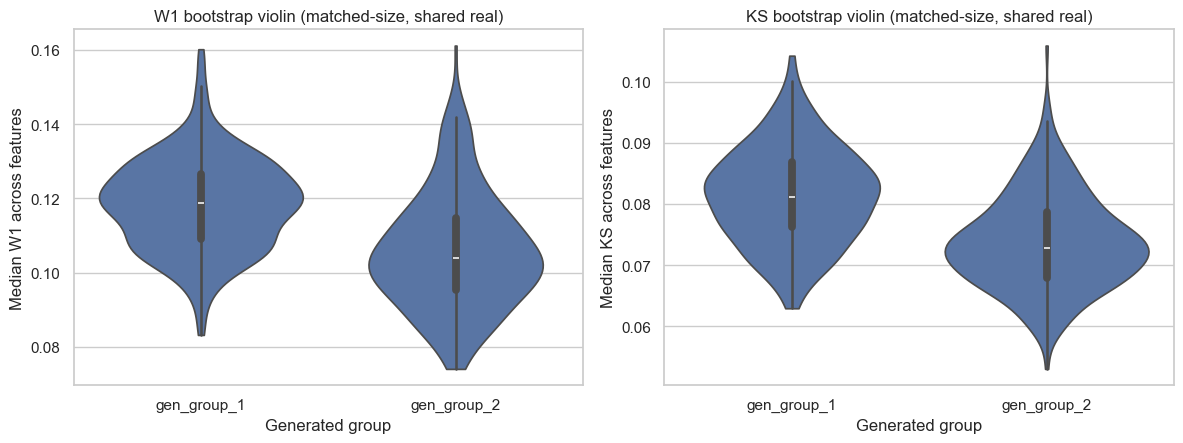

In [14]:
# Chunk 6 — B. Marginals. Matched-size bootstrap → median W1 / median KS per replicate; violins only.

from scipy.stats import wasserstein_distance, ks_2samp


def _matched_size_bootstrap_indices(n_real: int, n_gen: int, n_sample: int, rng: np.random.Generator):
    idx_r = rng.choice(n_real, size=n_sample, replace=True)
    idx_g = rng.choice(n_gen, size=n_sample, replace=True)
    return idx_r, idx_g


def _compute_bootstrap_w1_ks(real_df: pd.DataFrame, gen_df: pd.DataFrame, group_name: str, n_bootstrap: int, seed: int) -> pd.DataFrame:
    rng = np.random.default_rng(seed)

    common_cols = [c for c in real_df.columns if c in gen_df.columns]
    real_x = real_df[common_cols].to_numpy(dtype=float)
    gen_x = gen_df[common_cols].to_numpy(dtype=float)

    n_real = real_x.shape[0]
    n_gen = gen_x.shape[0]
    n_sample = min(n_real, n_gen)  # matched-size

    records = []
    for b in range(n_bootstrap):
        idx_r, idx_g = _matched_size_bootstrap_indices(n_real, n_gen, n_sample, rng)
        r_b = real_x[idx_r, :]
        g_b = gen_x[idx_g, :]

        w1_vals = []
        ks_vals = []
        for j in range(r_b.shape[1]):
            r_col = r_b[:, j]
            g_col = g_b[:, j]

            w1_vals.append(float(wasserstein_distance(r_col, g_col)))
            ks_vals.append(float(ks_2samp(r_col, g_col, alternative="two-sided", method="asymp").statistic))

        records.append(
            {
                "group": group_name,
                "bootstrap_id": b,
                "W1_median": float(np.median(w1_vals)),
                "KS_median": float(np.median(ks_vals)),
            }
        )

    return pd.DataFrame(records)


# Run bootstrap for each generated group
bootstrap_tables = []
for i, (group_name, data_obj) in enumerate(prepared.items()):
    tbl = _compute_bootstrap_w1_ks(
        real_df=data_obj["real"],
        gen_df=data_obj["gen"],
        group_name=group_name,
        n_bootstrap=N_BOOTSTRAP,
        seed=BOOTSTRAP_RANDOM_SEED + i,
    )
    bootstrap_tables.append(tbl)

bootstrap_w1_ks = pd.concat(bootstrap_tables, ignore_index=True)

# Long format for plotting
plot_df = bootstrap_w1_ks.melt(
    id_vars=["group", "bootstrap_id"],
    value_vars=["W1_median", "KS_median"],
    var_name="metric",
    value_name="value",
)

print("Bootstrap summary (median over features per replicate):")
display(
    bootstrap_w1_ks.groupby("group")[["W1_median", "KS_median"]].agg(["median", "mean", "std"])
)

# -------------------------------
# Violin plots branch logic
# -------------------------------
if USE_SHARED_REAL_FOR_ALL_GENERATORS:
    # Shared real: compare all generated groups in one figure
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

    sns.violinplot(
        data=plot_df[plot_df["metric"] == "W1_median"],
        x="group",
        y="value",
        inner="box",
        cut=0,
        ax=axes[0],
    )
    axes[0].set_title("W1 bootstrap violin (matched-size, shared real)")
    axes[0].set_xlabel("Generated group")
    axes[0].set_ylabel("Median W1 across features")

    sns.violinplot(
        data=plot_df[plot_df["metric"] == "KS_median"],
        x="group",
        y="value",
        inner="box",
        cut=0,
        ax=axes[1],
    )
    axes[1].set_title("KS bootstrap violin (matched-size, shared real)")
    axes[1].set_xlabel("Generated group")
    axes[1].set_ylabel("Median KS across features")

    plt.tight_layout()
    plt.show()
else:
    # Separate reals: show one figure per group
    for group_name in bootstrap_w1_ks["group"].unique():
        gdf = plot_df[plot_df["group"] == group_name].copy()

        plt.figure(figsize=(8.4, 4.6))
        sns.violinplot(
            data=gdf,
            x="metric",
            y="value",
            order=["W1_median", "KS_median"],
            inner="box",
            cut=0,
        )
        plt.title(f"Bootstrap violin (matched-size) — {group_name}")
        plt.xlabel("Metric")
        plt.ylabel("Median distance across features")
        plt.tight_layout()
        plt.show()

c:\Users\17376\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\17376\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


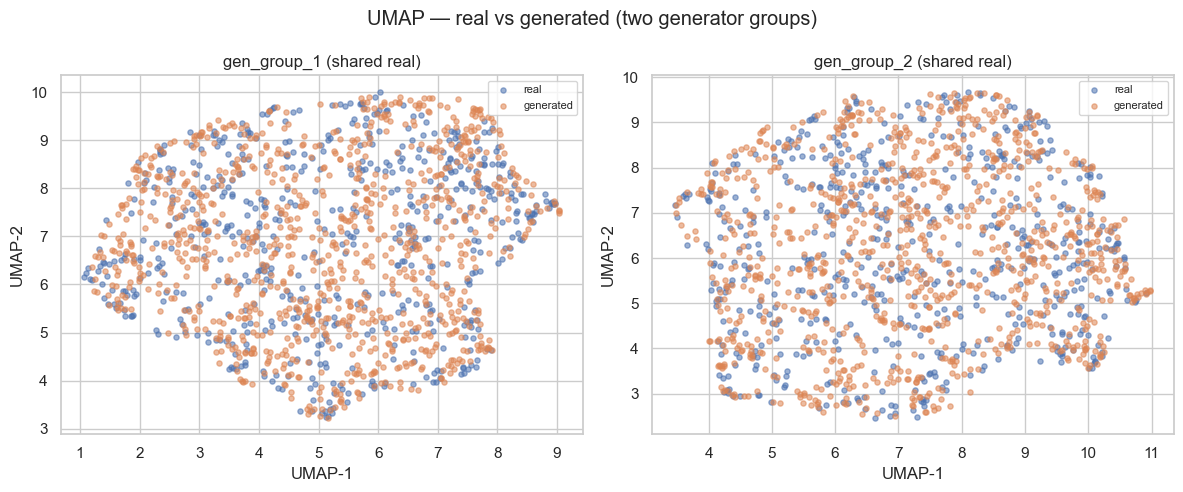

In [15]:
# Chunk 7 — C.1 UMAP. Real vs gen in 2D (shared real: 1×2 subplots; separate: one figure per group).

from sklearn.preprocessing import StandardScaler

try:
    import umap  # type: ignore
    HAS_UMAP = True
except Exception as e:
    HAS_UMAP = False
    print("UMAP not available:", repr(e))


def _fit_umap_2d(real_df: pd.DataFrame, gen_df: pd.DataFrame, random_state: int = 42):
    cols = [c for c in real_df.columns if c in gen_df.columns]
    X = np.vstack([real_df[cols].to_numpy(float), gen_df[cols].to_numpy(float)])
    n_real = len(real_df)
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)
    n_nb = min(15, max(2, Xs.shape[0] - 1))
    reducer = umap.UMAP(
        n_components=2,
        random_state=random_state,
        n_neighbors=n_nb,
        min_dist=0.1,
    )
    Z = reducer.fit_transform(Xs)
    return Z[:n_real], Z[n_real:]


def _plot_umap_on_ax(ax, z_real, z_gen, title: str) -> None:
    ax.scatter(z_real[:, 0], z_real[:, 1], alpha=0.55, s=14, label="real", rasterized=True)
    ax.scatter(z_gen[:, 0], z_gen[:, 1], alpha=0.55, s=14, label="generated", rasterized=True)
    ax.legend(loc="best", fontsize=8)
    ax.set_title(title)
    ax.set_xlabel("UMAP-1")
    ax.set_ylabel("UMAP-2")


if HAS_UMAP:
    if USE_SHARED_REAL_FOR_ALL_GENERATORS:
        fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=False, sharey=False)
        for ax, (gn, data) in zip(axes, prepared.items()):
            zr, zg = _fit_umap_2d(data["real"], data["gen"])
            _plot_umap_on_ax(ax, zr, zg, f"{gn} (shared real)")
        fig.suptitle("UMAP — real vs generated (two generator groups)")
        fig.tight_layout()
        plt.show()
    else:
        for gn, data in prepared.items():
            fig, ax = plt.subplots(1, 1, figsize=(6, 5))
            zr, zg = _fit_umap_2d(data["real"], data["gen"])
            _plot_umap_on_ax(ax, zr, zg, gn)
            fig.tight_layout()
            plt.show()


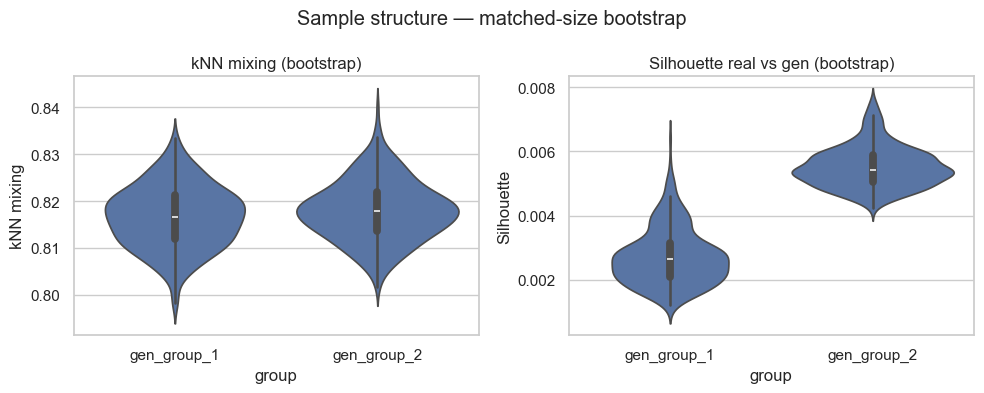

group              gen_group_1  gen_group_2
knn_mixing median     0.816556     0.817826
           mean       0.816654     0.817965
           std        0.006622     0.006371
silhouette median     0.002639     0.005415
           mean       0.002724     0.005523
           std        0.000876     0.000633

In [16]:
# Chunk 8 — C.2 Sample structure. Matched-size bootstrap → kNN mixing + silhouette; violins (same branch as B).

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score

K_NEIGHBORS_STRUCTURE = 15


def _effective_k(n_points: int, k: int) -> int:
    return max(2, min(k, n_points - 1))


def knn_mixing_score(X: np.ndarray, y_is_real: np.ndarray, k: int) -> float:
    """Higher => neighborhood label proportions closer to global mix (more mixed real/gen)."""
    n = X.shape[0]
    k_use = _effective_k(n, k)
    p_global = float(np.mean(y_is_real))
    nn = NearestNeighbors(n_neighbors=k_use + 1, algorithm="auto")
    nn.fit(X)
    _, inds = nn.kneighbors(X)
    neigh = inds[:, 1 : k_use + 1]
    p_local = np.mean(y_is_real[neigh], axis=1)
    return float(1.0 - np.mean(np.abs(p_local - p_global)))


def bootstrap_knn_silhouette(
    real_df: pd.DataFrame,
    gen_df: pd.DataFrame,
    group_name: str,
    n_bootstrap: int,
    seed: int,
) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    cols = [c for c in real_df.columns if c in gen_df.columns]
    real_x = real_df[cols].to_numpy(float)
    gen_x = gen_df[cols].to_numpy(float)
    n_real, n_gen = real_x.shape[0], gen_x.shape[0]
    n_sample = min(n_real, n_gen)
    rows: list[dict] = []
    for b in range(n_bootstrap):
        ir = rng.choice(n_real, size=n_sample, replace=True)
        ig = rng.choice(n_gen, size=n_sample, replace=True)
        r_b = real_x[ir]
        g_b = gen_x[ig]
        X = np.vstack([r_b, g_b])
        y = np.array([1] * n_sample + [0] * n_sample, dtype=np.int32)
        scaler = StandardScaler()
        Xs = scaler.fit_transform(X)
        mix = knn_mixing_score(Xs, y, K_NEIGHBORS_STRUCTURE)
        try:
            sil = float(silhouette_score(Xs, y, metric="euclidean"))
        except ValueError:
            sil = float("nan")
        rows.append(
            {
                "group": group_name,
                "bootstrap_id": b,
                "knn_mixing": mix,
                "silhouette": sil,
            }
        )
    return pd.DataFrame(rows)


parts: list[pd.DataFrame] = []
for i, (gn, data) in enumerate(prepared.items()):
    parts.append(
        bootstrap_knn_silhouette(
            data["real"],
            data["gen"],
            gn,
            n_bootstrap=N_BOOTSTRAP,
            seed=BOOTSTRAP_RANDOM_SEED + i,
        )
    )
bootstrap_structure_df = pd.concat(parts, ignore_index=True)

if USE_SHARED_REAL_FOR_ALL_GENERATORS:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    sns.violinplot(
        data=bootstrap_structure_df,
        x="group",
        y="knn_mixing",
        ax=axes[0],
        inner="box",
    )
    axes[0].set_title("kNN mixing (bootstrap)")
    axes[0].set_ylabel("kNN mixing")
    sns.violinplot(
        data=bootstrap_structure_df,
        x="group",
        y="silhouette",
        ax=axes[1],
        inner="box",
    )
    axes[1].set_title("Silhouette real vs gen (bootstrap)")
    axes[1].set_ylabel("Silhouette")
    fig.suptitle("Sample structure — matched-size bootstrap")
    fig.tight_layout()
    plt.show()
else:
    for gn in prepared:
        sub = bootstrap_structure_df.loc[bootstrap_structure_df["group"] == gn]
        fig, axes = plt.subplots(1, 2, figsize=(8, 4))
        sns.violinplot(data=sub, y="knn_mixing", ax=axes[0], inner="box", color="C0")
        axes[0].set_title("kNN mixing (bootstrap)")
        axes[0].set_xticks([])
        sns.violinplot(data=sub, y="silhouette", ax=axes[1], inner="box", color="C1")
        axes[1].set_title("Silhouette (bootstrap)")
        axes[1].set_xticks([])
        fig.suptitle(f"{gn} — matched-size bootstrap")
        fig.tight_layout()
        plt.show()

display(
    bootstrap_structure_df.groupby("group")[["knn_mixing", "silhouette"]]
    .agg(["median", "mean", "std"])
    .T
)


c:\Users\17376\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\17376\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
c:\Users\17376\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\17376\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
c:\Users\17376\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\17376\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
c:\Users\17376\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: in

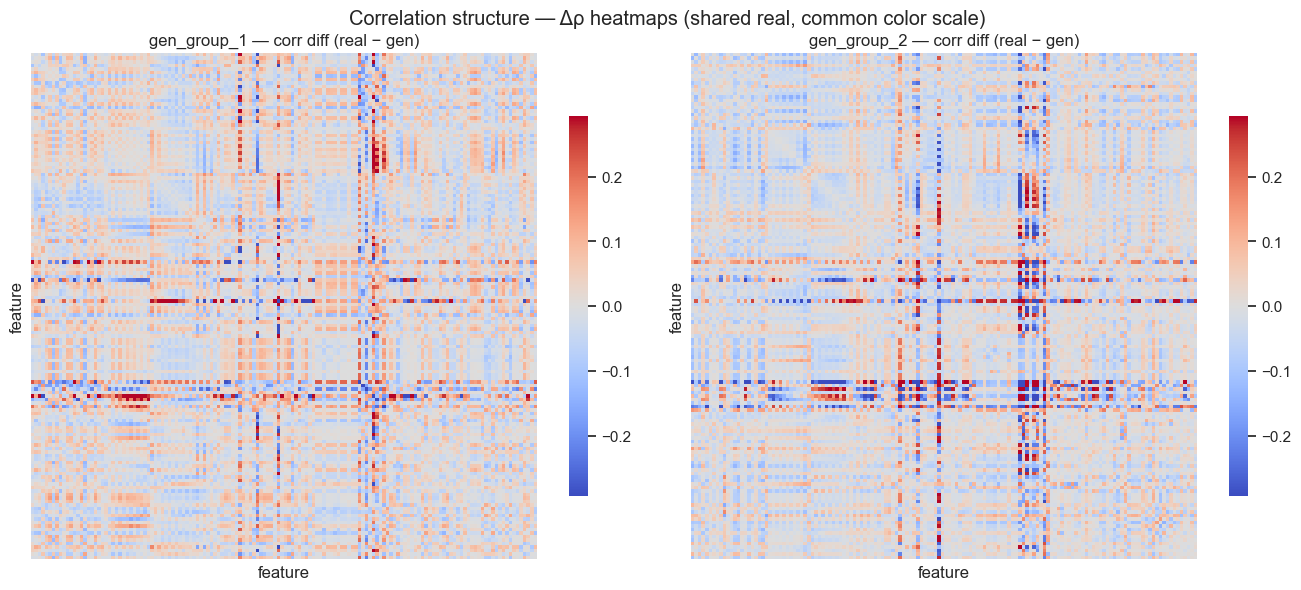

In [17]:
# Chunk 9 — D.1 Correlation heatmaps. Full-sample Δρ = R_real − R_gen (shared: common color scale).

def _corr_matrix_from_samples(X: np.ndarray) -> np.ndarray:
    """Pearson correlation across columns; rows are observations."""
    C = np.corrcoef(X, rowvar=False)
    return np.nan_to_num(C, nan=0.0, posinf=0.0, neginf=0.0)


def _corr_diff_heatmap(
    real_df: pd.DataFrame,
    gen_df: pd.DataFrame,
    ax,
    title: str,
    vmax: float | None,
) -> float:
    cols = [c for c in real_df.columns if c in gen_df.columns]
    Cr = _corr_matrix_from_samples(real_df[cols].to_numpy(dtype=float))
    Cg = _corr_matrix_from_samples(gen_df[cols].to_numpy(dtype=float))
    diff = Cr - Cg
    dfd = pd.DataFrame(diff, index=cols, columns=cols)
    if vmax is None:
        v = float(np.quantile(np.abs(diff), 0.99)) if diff.size else 1.0
        v = max(v, 1e-6)
    else:
        v = max(float(vmax), 1e-6)
    sns.heatmap(
        dfd,
        cmap="coolwarm",
        center=0.0,
        vmin=-v,
        vmax=v,
        ax=ax,
        square=True,
        xticklabels=False,
        yticklabels=False,
        cbar_kws={"shrink": 0.75},
    )
    ax.set_title(title)
    ax.set_xlabel("feature")
    ax.set_ylabel("feature")
    return v


# Shared color limit so the two panels are comparable
if USE_SHARED_REAL_FOR_ALL_GENERATORS:
    vmax_shared = 0.0
    for _gn, data in prepared.items():
        cols = [c for c in data["real"].columns if c in data["gen"].columns]
        Cr = _corr_matrix_from_samples(data["real"][cols].to_numpy(dtype=float))
        Cg = _corr_matrix_from_samples(data["gen"][cols].to_numpy(dtype=float))
        d = Cr - Cg
        vmax_shared = max(vmax_shared, float(np.quantile(np.abs(d), 0.99)) if d.size else 1.0)
    vmax_shared = max(vmax_shared, 1e-6)

    fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.8))
    for ax, (gn, data) in zip(axes, prepared.items()):
        _corr_diff_heatmap(data["real"], data["gen"], ax, f"{gn} — corr diff (real − gen)", vmax_shared)
    fig.suptitle("Correlation structure — Δρ heatmaps (shared real, common color scale)")
    fig.tight_layout()
    plt.show()
else:
    for gn, data in prepared.items():
        fig, ax = plt.subplots(1, 1, figsize=(7.2, 6.0))
        _corr_diff_heatmap(data["real"], data["gen"], ax, f"{gn} — corr diff (real − gen)", None)
        fig.suptitle("Correlation structure — Δρ heatmap")
        fig.tight_layout()
        plt.show()


c:\Users\17376\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\17376\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
c:\Users\17376\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\17376\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Bootstrap summary — correlation structure scalars:


median_abs_delta_rho                     frobenius_delta_R                      mantel_corr                    
                          median      mean       std            median       mean       std      median      mean       std
group                                                                                                                      
gen_group_1             0.049244  0.049695  0.006470         12.577380  12.732691  0.981136    0.975408  0.974509  0.004276
gen_group_2             0.047638  0.048109  0.006044         13.706055  13.781204  0.739180    0.973551  0.973300  0.003205

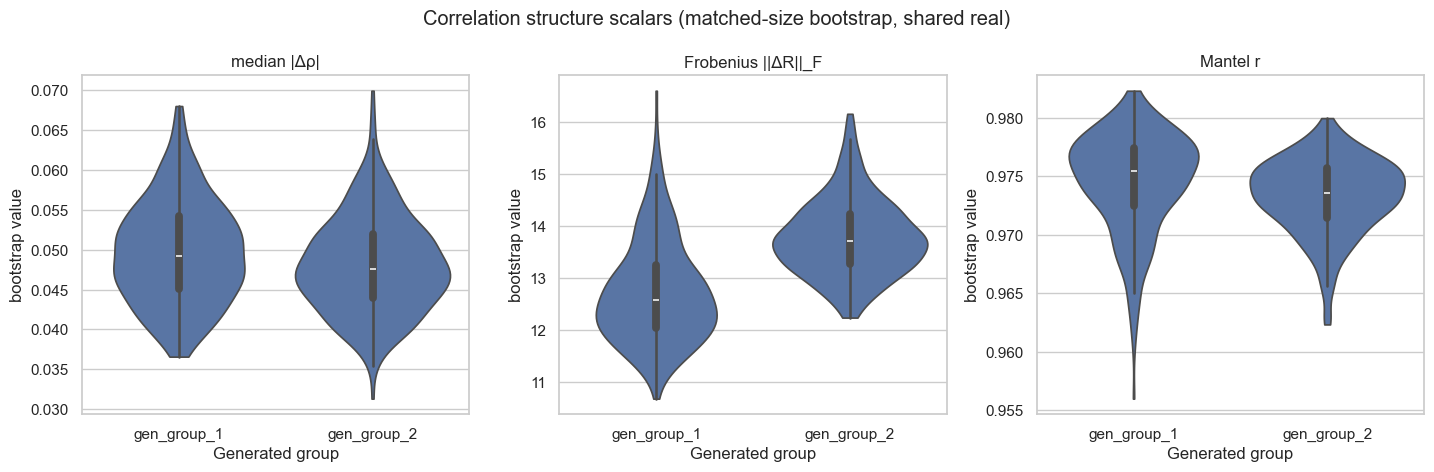

In [18]:
# Chunk 10 — D.2 Correlation scalars. Matched-size bootstrap → median|Δρ|, Frobenius, Mantel; violins.

def _corr_matrix_from_samples(X: np.ndarray) -> np.ndarray:
    C = np.corrcoef(X, rowvar=False)
    return np.nan_to_num(C, nan=0.0, posinf=0.0, neginf=0.0)


def _matched_bs_idx_corr(n_real: int, n_gen: int, n_sample: int, rng: np.random.Generator):
    return rng.choice(n_real, size=n_sample, replace=True), rng.choice(n_gen, size=n_sample, replace=True)


def _corr_structure_scalars(Cr: np.ndarray, Cg: np.ndarray) -> tuple[float, float, float]:
    """ΔR = R_real − R_gen; median|Δρ| on off-diagonal; Frobenius on full ΔR; Mantel = cor(utri(Rr), utri(Rg))."""
    dR = Cr - Cg
    p = Cr.shape[0]
    mask = ~np.eye(p, dtype=bool)
    med_abs = float(np.median(np.abs(dR[mask])))
    frob = float(np.linalg.norm(dR, ord="fro"))
    iu = np.triu_indices(p, k=1)
    vr = Cr[iu]
    vg = Cg[iu]
    if np.std(vr) < 1e-12 or np.std(vg) < 1e-12:
        mantel = float("nan")
    else:
        mantel = float(np.corrcoef(vr, vg)[0, 1])
    return med_abs, frob, mantel


def _bootstrap_corr_scalars(
    real_df: pd.DataFrame,
    gen_df: pd.DataFrame,
    group_name: str,
    n_bootstrap: int,
    seed: int,
) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    cols = [c for c in real_df.columns if c in gen_df.columns]
    real_x = real_df[cols].to_numpy(dtype=float)
    gen_x = gen_df[cols].to_numpy(dtype=float)
    n_real, n_gen = real_x.shape[0], gen_x.shape[0]
    n_sample = min(n_real, n_gen)
    rows: list[dict] = []
    for b in range(n_bootstrap):
        ir, ig = _matched_bs_idx_corr(n_real, n_gen, n_sample, rng)
        Cr = _corr_matrix_from_samples(real_x[ir])
        Cg = _corr_matrix_from_samples(gen_x[ig])
        med_abs, frob, mantel = _corr_structure_scalars(Cr, Cg)
        rows.append(
            {
                "group": group_name,
                "bootstrap_id": b,
                "median_abs_delta_rho": med_abs,
                "frobenius_delta_R": frob,
                "mantel_corr": mantel,
            }
        )
    return pd.DataFrame(rows)


bootstrap_corr_tables = []
for i, (group_name, data_obj) in enumerate(prepared.items()):
    bootstrap_corr_tables.append(
        _bootstrap_corr_scalars(
            data_obj["real"],
            data_obj["gen"],
            group_name,
            n_bootstrap=N_BOOTSTRAP,
            seed=BOOTSTRAP_RANDOM_SEED + i,
        )
    )
bootstrap_corr_scalars = pd.concat(bootstrap_corr_tables, ignore_index=True)

value_cols = ["median_abs_delta_rho", "frobenius_delta_R", "mantel_corr"]
corr_plot_df = bootstrap_corr_scalars.melt(
    id_vars=["group", "bootstrap_id"],
    value_vars=value_cols,
    var_name="metric",
    value_name="value",
)
_metric_labels = {
    "median_abs_delta_rho": "median |Δρ|",
    "frobenius_delta_R": "Frobenius ||ΔR||_F",
    "mantel_corr": "Mantel r",
}
corr_plot_df["metric_label"] = corr_plot_df["metric"].map(_metric_labels)

print("Bootstrap summary — correlation structure scalars:")
display(bootstrap_corr_scalars.groupby("group")[value_cols].agg(["median", "mean", "std"]))

if USE_SHARED_REAL_FOR_ALL_GENERATORS:
    fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.8))
    for ax, mkey, mlab in zip(
        axes,
        ["median_abs_delta_rho", "frobenius_delta_R", "mantel_corr"],
        [_metric_labels[k] for k in ["median_abs_delta_rho", "frobenius_delta_R", "mantel_corr"]],
    ):
        sub = corr_plot_df[corr_plot_df["metric"] == mkey]
        sns.violinplot(data=sub, x="group", y="value", inner="box", cut=0, ax=ax)
        ax.set_title(mlab)
        ax.set_xlabel("Generated group")
        ax.set_ylabel("bootstrap value")
    fig.suptitle("Correlation structure scalars (matched-size bootstrap, shared real)")
    fig.tight_layout()
    plt.show()
else:
    metric_order = [
        "median_abs_delta_rho",
        "frobenius_delta_R",
        "mantel_corr",
    ]
    for group_name in bootstrap_corr_scalars["group"].unique():
        gdf = corr_plot_df[corr_plot_df["group"] == group_name].copy()
        plt.figure(figsize=(9.0, 4.8))
        ax = plt.gca()
        sns.violinplot(
            data=gdf,
            x="metric",
            y="value",
            order=metric_order,
            inner="box",
            cut=0,
            ax=ax,
        )
        ax.set_xticklabels([_metric_labels[m] for m in metric_order])
        plt.title(f"Correlation structure scalars (matched-size bootstrap) — {group_name}")
        plt.xlabel("Metric")
        plt.ylabel("bootstrap value")
        plt.tight_layout()
        plt.show()
